<h2 style="font-family:Comic Sans MS; color:#2bb5bd">1. Online Food Dataset</h2>

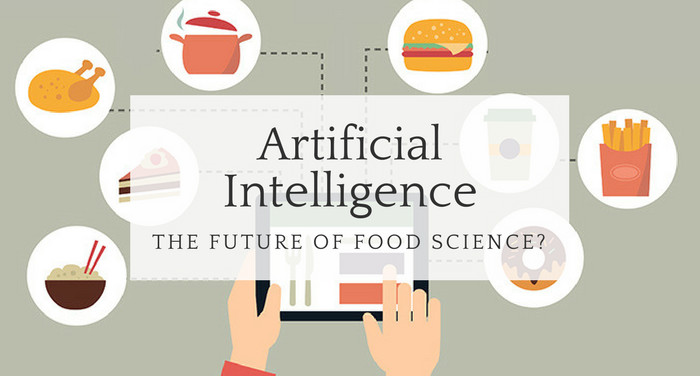

<div style="text-align: left;">
    <table>
        <tr>
            <th><b>Attribute</b></th>
            <th><b>Details</b></th>
        </tr>
        <tr>
            <td><b>Author</b></td>
            <td><b>Muhammad Tayyab Ali</b></td>
        </tr>
        <tr>
            <td>GitHub</td>
            <td><a href="https://github.com/TayyabAli92"><img src="https://img.shields.io/badge/GitHub-Profile-red?style=for-the-badge&logo=github" alt="GitHub"/></a></td>
        </tr>
        <tr>
            <td>LinkedIn</td>
            <td><a href="https://www.linkedin.com/in/tayyab-ali-personal-86a3582b8/"><img src="https://img.shields.io/badge/LinkedIn-Profile-red?style=for-the-badge&logo=linkedin" alt="LinkedIn"/></a></td>
        </tr>
        <tr>
            <td>Twitter</td>
            <td><a href="https://twitter.com/Tayyab_Ali92"><img src="https://img.shields.io/badge/Twitter-Profile-red?style=for-the-badge&logo=twitter" alt="Twitter"/></a></td>
        </tr>
        <tr>
            <td>Facebook</td>
            <td><a href="https://www.facebook.com/profile.php?id=61556758989955"><img src="https://img.shields.io/badge/Facebook-Profile-red?style=for-the-badge&logo=facebook" alt="Facebook"/></a></td>
        </tr>
        <tr>
            <td>Gmail</td>
            <td><a href="tayyabali.personal@gmail.com"><img src="https://img.shields.io/badge/Gmail-Contact%20Me-green?style=for-the-badge&logo=gmail" alt="Gmail"/></a></td>
        </tr>
    </table>
</div>

<h2 style="font-family:Comic Sans MS; color:#2bb5bd">2. Import libraries</h2>

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

<h2 style="font-family:Comic Sans MS; color:#2bb5bd">3. load the Dataset</h2>

In [ ]:
df = pd.read_csv("/kaggle/input/online-food-dataset/onlinefoods.csv")

In [ ]:
df.head()

<h2 style="font-family:Comic Sans MS; color:#2bb5bd">4. Data Preprocessing</h2>

In [ ]:
df.drop(columns='Unnamed: 12', inplace=True)

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.describe()

In [ ]:
df.head()

In [ ]:
age_counts = df['Age'].value_counts().sort_index()

plt.bar(age_counts.index, age_counts.values, color='green', edgecolor='black')
plt.title('Distribution of Ages', fontsize=16)
plt.xlabel('Ages', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Marital Status'], df['Educational Qualifications'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies table:")
print(expected)

In [ ]:
pd.DataFrame(df.groupby('Monthly Income'))[0]

In [ ]:
df.loc[df['Monthly Income'] == '10001 to 25000', 'Monthly Income'] = 17500
df.loc[df['Monthly Income'] == '25001 to 50000', 'Monthly Income'] = 37500
df.loc[df['Monthly Income'] == 'Below Rs.10000', 'Monthly Income'] = 10000
df.loc[df['Monthly Income'] == 'More than 50000', 'Monthly Income'] = 50000
df.loc[df['Monthly Income'] == 'No Income', 'Monthly Income'] = 0

In [ ]:
df['Monthly Income'] = df['Monthly Income'].astype(int)

In [ ]:
pd.DataFrame(df.groupby('Marital Status')['Monthly Income'].mean().sort_values(ascending=False))

In [ ]:
income_pattern = df.groupby('Occupation')['Monthly Income'].mean()

plt.figure(figsize=(6,4))
plt.bar(income_pattern.index, income_pattern.values, color='lightpink', edgecolor='black')
plt.title('Income Patterns')
plt.xlabel('Occupation')
plt.ylabel('Income')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.head()

<h2 style="font-family:Comic Sans MS; color:#2bb5bd">5. Traning Model</h2>

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Monthly Income'),
                                                     df['Monthly Income'],
                                                     test_size=0.2, random_state=42)

In [ ]:
pd.DataFrame(X_train).head()

In [ ]:
X_train.shape

In [ ]:
numerical_columns = [0, 5, 6, 7, 8]
cat_nominal = [1, 2, 3]
cat_ordinal = [5, 9, 10]

In [ ]:
handle_numerical = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean'))
])

In [ ]:
handle_nominal = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(drop='first'))
])

In [ ]:
handle_ordinal = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder())
])

In [ ]:
preprocessing = ColumnTransformer(transformers=[
    ('numerical', handle_numerical, numerical_columns),
    ('nominal', handle_nominal, cat_nominal),
    ('ordinal', handle_ordinal, cat_ordinal)
])

In [ ]:
model = LinearRegression()

In [ ]:
pipe = make_pipeline(preprocessing, model)

In [ ]:
pipe.fit(X_train, y_train)

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2) Score:", r2)